### <font color = "gold"> Import les librairies requises

In [1]:
# Importer les packages
import pandas as pd
import numpy as np
import plotly.express as px

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
 # Supprimer les warnings
 import warnings
 warnings.filterwarnings('ignore')

### <font color = "gold"> Importer et lire les données

In [4]:
# Importer les données
df= pd.read_csv('/content/drive/MyDrive/ML-AI-HUB/Unsupervised Learning /Clustering/Doc 1/wheat_seeds_dataset.csv')
df.head()

,area A,perimeter,compactness,length of kernel,width of kernel,asymmetry coefficient,length of kernel groove
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175


**Nous avons ici des données de graines de blé. Chaque graine de blé est caractérisée par 7 variables morphologiques (issues de l'étude morphologique de chaque graine).**

In [5]:
# Afficher les données
df.head( )

,area A,perimeter,compactness,length of kernel,width of kernel,asymmetry coefficient,length of kernel groove
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175


In [6]:
# Dimension des données
df.shape

(199, 7)

In [7]:
# Infos des données
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199 entries, 0 to 198
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   area A                   199 non-null    float64
 1   perimeter                199 non-null    float64
 2   compactness              199 non-null    float64
 3   length of kernel         199 non-null    float64
 4   width of kernel          199 non-null    float64
 5   asymmetry coefficient    199 non-null    float64
 6   length of kernel groove  199 non-null    float64
dtypes: float64(7)
memory usage: 11.0 KB


In [8]:
# Décrire les données
df.describe().T

,count,mean,std,min,25%,50%,75%,max
area A,199.0,14.918744,2.919976,10.5900,12.3300,14.4300,17.4550,21.1800
perimeter,199.0,14.595829,1.310445,12.4100,13.4700,14.3700,15.8050,17.2500
compactness,199.0,0.870811,0.023320,0.8081,0.8571,0.8734,0.8868,0.9183
length of kernel,199.0,5.643151,0.443593,4.8990,5.2670,5.5410,6.0020,6.6750
width of kernel,199.0,3.265533,0.378322,2.6300,2.9545,3.2450,3.5645,4.0330
asymmetry coefficient,199.0,3.699217,1.471102,0.7651,2.5700,3.6310,4.7990,8.3150
length of kernel groove,199.0,5.420653,0.492718,4.5190,5.0460,5.2280,5.8790,6.5500


In [9]:
# Renommer les index
for i in range(len(df)):
  df.rename(index={i: 'graine' + str(i+1)}, inplace= True )
#Afficher df
df.head()

,area A,perimeter,compactness,length of kernel,width of kernel,asymmetry coefficient,length of kernel groove
graine1,15.26,14.84,0.8710,5.763,3.312,2.221,5.220
graine2,14.88,14.57,0.8811,5.554,3.333,1.018,4.956
graine3,14.29,14.09,0.9050,5.291,3.337,2.699,4.825
graine4,13.84,13.94,0.8955,5.324,3.379,2.259,4.805
graine5,16.14,14.99,0.9034,5.658,3.562,1.355,5.175


In [10]:
# Matrice des données
x = df.values
x[:5]

array([[15.26  , 14.84  ,  0.871 ,  5.763 ,  3.312 ,  2.221 ,  5.22  ],
       [14.88  , 14.57  ,  0.8811,  5.554 ,  3.333 ,  1.018 ,  4.956 ],
       [14.29  , 14.09  ,  0.905 ,  5.291 ,  3.337 ,  2.699 ,  4.825 ],
       [13.84  , 13.94  ,  0.8955,  5.324 ,  3.379 ,  2.259 ,  4.805 ],
       [16.14  , 14.99  ,  0.9034,  5.658 ,  3.562 ,  1.355 ,  5.175 ]])

#### <font color = "gold"> Appliquer une ACP

In [11]:
# Importer PCA
from sklearn.decomposition import PCA
#Instantier le modèle PCA avec n_components = 2
pca = PCA(n_components= 2)

# Matrice des 2 composantes
features_pca= pca.fit_transform(x)
# Dataframe
df_pca = pd.DataFrame(features_pca, columns = ['PC 1', 'PC 2'])
df_pca.head()

,PC 1,PC 2
0,0.570123,-1.432173
1,0.212147,-2.701350
2,-0.751217,-1.135894
3,-1.150036,-1.622382
4,1.520551,-2.206036


In [12]:
# Part de variance des 2 composantes
print(round(sum(pca.explained_variance_ratio_*100),2), '%')

99.3 %


### <font color = "gold"> Kmeans

In [13]:
# Importer KMeans
from sklearn.cluster import KMeans

In [14]:
# rechercher le k optimal
inertia = []
for k in range(2, 11):
  # Instantier le modèle kmeans
  kmeans_model = KMeans(n_clusters= k,init = 'random', max_iter=500)
  kmeans_model.fit(x)
  # Rajouter le inertia sur liste inertia
  inertia.append(kmeans_model.inertia_)

In [15]:
# #
# for i in range(2,11):
#   print(f'K = {i} --- Inertia : {inertia[i-2]}')
#   print('------------------------------')
# visualiser le elbow
import plotly.express as px
fig = px.line(x = list(range(2, 11)), y = inertia)
fig.show()

##### <font color = "bisque"> La méthode elbow(coude)

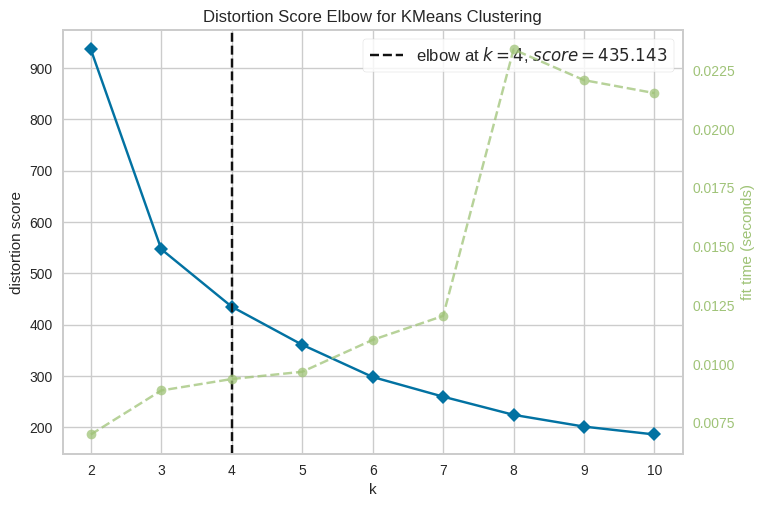

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [16]:
# importer KELbowVisualizer
from yellowbrick.cluster import KElbowVisualizer
# Instantier le modèle kmeans
kmeans_model = KMeans(init = 'random', max_iter=500)
# Instantier KELbowVisualizer
Elbow_M = KElbowVisualizer(kmeans_model, k=10)
# Entrainement
Elbow_M.fit(x)
# Visualiser l'elbow
Elbow_M.show()

#### <font color = "bisque"> Appliquer Kmeans en utilisant le k optimal

In [34]:
# Initier le modèle
kmeans_model = KMeans(n_clusters = 5, init= 'random', max_iter = 500)
# Entrainer le modèle
kmeans_model.fit(x)

KMeans(init='random', max_iter=500, n_clusters=5)

#### <font color = "bisque"> Prédiction la partition

In [35]:
# Prediction de la partition(l'ensemble des classes) de X
kmeans_partition = kmeans_model.predict(x)
# Afficher la partition
kmeans_partition

array([4, 4, 4, 4, 4, 4, 4, 3, 3, 3, 4, 4, 4, 4, 4, 0, 4, 4, 1, 4, 4, 4,
       1, 4, 4, 1, 1, 4, 1, 4, 3, 4, 4, 4, 3, 3, 4, 0, 4, 4, 1, 3, 4, 4,
       4, 4, 4, 4, 4, 3, 4, 4, 4, 4, 4, 4, 4, 1, 1, 1, 1, 1, 1, 4, 4, 1,
       3, 3, 3, 2, 3, 3, 3, 2, 2, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 3, 2, 2, 2, 2, 3, 2, 2, 2, 2, 2, 3, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 3, 2, 3, 2, 2, 2, 2, 3, 2, 2, 3, 3, 3, 3, 4,
       4, 3, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1,
       0], dtype=int32)

In [36]:
# Nombre d'observations dans chaque classe
val_cluster = pd.Series(kmeans_partition).value_counts()
val_cluster

,count
0,48
2,47
4,45
1,32
3,27


In [37]:
# Diagramme en barre du nombre d'observations dans chaque
fig= px.bar(x = val_cluster.index, y =val_cluster.values, color= val_cluster.index.astype(str), text_auto =True)
fig.show()

#### <font color = "bisque"> Visualiser les classes prédictes par Kmeans

In [38]:
# Visualiser les classes suivant les deux composantes en utilisant plotly.express
fig = px.scatter(df_pca, x = 'PC 1', y = 'PC 2', color = kmeans_partition.astype(str))
fig.show()

<font color = "bisque">Indice de silhouette value de la partition du Kmeans

In [39]:
# Importer silhouette score
from sklearn.metrics import silhouette_score
# Indice de Silhouette value
sil_kmeans = silhouette_score(x, kmeans_partition)
print(f"La silhouette est : {sil_kmeans: .2f}")

La silhouette est :  0.36


In [26]:
# Les graines de chaque classes
clusters_list = []
for i in range(4):
  clusters_list.append(list(df.index[kmeans_partition == i]))

In [33]:
# Afficher les graines de la classe 0
print(clusters_list[3])

['graine16', 'graine19', 'graine38', 'graine59', 'graine60', 'graine61', 'graine66', 'graine135', 'graine136', 'graine137', 'graine138', 'graine139', 'graine140', 'graine141', 'graine142', 'graine143', 'graine144', 'graine145', 'graine146', 'graine147', 'graine148', 'graine149', 'graine150', 'graine151', 'graine152', 'graine153', 'graine154', 'graine155', 'graine156', 'graine157', 'graine158', 'graine159', 'graine161', 'graine162', 'graine163', 'graine164', 'graine165', 'graine166', 'graine167', 'graine168', 'graine169', 'graine170', 'graine172', 'graine173', 'graine174', 'graine175', 'graine176', 'graine177', 'graine178', 'graine179', 'graine180', 'graine181', 'graine182', 'graine183', 'graine184', 'graine185', 'graine186', 'graine187', 'graine188', 'graine189', 'graine190', 'graine192', 'graine193', 'graine194', 'graine195', 'graine196', 'graine197', 'graine198', 'graine199']


---

### <font color='gold'> Comparaison des modèles (KMeans, CAH, DBSCAN)

Le notebook original ne testait que KMeans. Avant de déployer, on compare ici **trois algorithmes** (KMeans, CAH, DBSCAN), **avec et sans normalisation**, pour identifier objectivement le meilleur modèle — comme cela a été fait pour le projet de segmentation clients.

In [ ]:
from sklearn.preprocessing import normalize
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from sklearn.neighbors import NearestNeighbors

x_brut = df.values
x_norm = normalize(x_brut)

#### <font color='teal'> 1. KMeans : recherche du meilleur k (avec et sans normalisation)

In [ ]:
for nom, data in [("sans normalisation", x_brut), ("avec normalisation", x_norm)]:
    print(f"--- KMeans {nom} ---")
    for k in range(2, 9):
        km = KMeans(n_clusters=k, init='random', max_iter=500, n_init=10, random_state=42)
        pred_k = km.fit_predict(data)
        sil = silhouette_score(data, pred_k)
        print(f"k={k}: silhouette={sil:.3f}")
    print()

#### <font color='teal'> 2. CAH : recherche du meilleur nombre de classes (linkage='average')

In [ ]:
for nom, data in [("sans normalisation", x_brut), ("avec normalisation", x_norm)]:
    print(f"--- CAH {nom} ---")
    for k in range(2, 9):
        cah = AgglomerativeClustering(n_clusters=k, linkage='average')
        pred_c = cah.fit_predict(data)
        sil = silhouette_score(data, pred_c)
        print(f"k={k}: silhouette={sil:.3f}")
    print()

#### <font color='teal'> 3. DBSCAN : recherche de eps et min_samples (avec et sans normalisation)

On explore une grille de paramètres et on ne garde que les combinaisons produisant au moins 2 clusters avec un taux de bruit raisonnable.

In [ ]:
def meilleur_dbscan(data, eps_range, min_samples_range, seuil_bruit=0.25):
    resultats = []
    n = len(data)
    for min_samples in min_samples_range:
        for eps in eps_range:
            db = DBSCAN(eps=eps, min_samples=min_samples)
            pred_d = db.fit_predict(data)
            n_clusters = len(set(pred_d)) - (1 if -1 in pred_d else 0)
            n_bruit = list(pred_d).count(-1)
            if n_clusters >= 2 and n_bruit < n * seuil_bruit:
                mask = pred_d != -1
                sil = silhouette_score(data[mask], pred_d[mask])
                resultats.append((min_samples, eps, n_clusters, n_bruit, sil))
    resultats.sort(key=lambda r: -r[4])
    return resultats

print("--- DBSCAN sans normalisation (top 5) ---")
for r in meilleur_dbscan(x_brut, np.arange(0.5, 2.0, 0.05), [5,7,9,11,14])[:5]:
    print(f"min_samples={r[0]}, eps={r[1]:.2f} -> clusters={r[2]}, bruit={r[3]} ({r[3]/len(df)*100:.1f}%), silhouette={r[4]:.3f}")

print("\n--- DBSCAN avec normalisation (top 5) ---")
for r in meilleur_dbscan(x_norm, np.arange(0.01, 0.09, 0.001), [3,4,5,7,9,11,14])[:5]:
    print(f"min_samples={r[0]}, eps={r[1]:.3f} -> clusters={r[2]}, bruit={r[3]} ({r[3]/len(df)*100:.1f}%), silhouette={r[4]:.3f}")

#### <font color='teal'> 4. Tableau récapitulatif

| Modèle | Normalisation | Paramètres | Clusters | Bruit | Silhouette |
|---|---|---|---|---|---|
| KMeans | Non | k=2 | 2 | - | 0.530 |
| KMeans | Oui | k=2 | 2 | - | 0.499 |
| CAH (average) | Non | k=2 | 2 | - | 0.506 |
| CAH (average) | Oui | k=2 | 2 | - | 0.484 |
| DBSCAN | Non | eps=1.25, min_samples=14 | 2 | 9.0% | 0.538 |
| **DBSCAN** | **Oui** | **eps=0.026, min_samples=9** | **2** | **18.6%** | **0.549** |

➡️ **DBSCAN** obtient le meilleur score de silhouette dans les deux configurations (normalisée et non normalisée), il devance nettement KMeans et la CAH quelle que soit la normalisation.

Entre les deux variantes de DBSCAN, l'écart de silhouette est faible (0.549 vs 0.538) mais la version **sans normalisation** génère beaucoup moins de bruit (9.0 % vs 18.6 % de graines classées « anomalies »). C'est donc **DBSCAN sans normalisation (eps=1.25, min_samples=14)** qui est retenu pour le déploiement : performance quasi identique, pour une application plus utilisable en pratique.

---

### <font color='gold'> Déploiement du modèle final (DBSCAN) avec Streamlit

Comme dans le projet de segmentation clients, DBSCAN n'a pas de méthode `predict()` : on réutilise la même stratégie de déploiement basée sur les **points cœur**.

In [ ]:
# Entraîner le modèle final retenu
dbscan_model = DBSCAN(eps=1.25, min_samples=14)
dbscan_model.fit(x_brut)

Predi = dbscan_model.labels_
mask = Predi != -1

sil_dbscan = silhouette_score(x_brut[mask], Predi[mask])
print(f"Silhouette DBSCAN (hors bruit) : {sil_dbscan:.3f}")
print(pd.Series(Predi).value_counts())

#### <font color='teal'> 1. Récupérer les points cœur de DBSCAN

In [ ]:
points_coeur = dbscan_model.components_
labels_coeur = dbscan_model.labels_[dbscan_model.core_sample_indices_]

print("Nombre de points cœur :", len(points_coeur))
print("Classes présentes      :", np.unique(labels_coeur))

#### <font color='teal'> 2. La fonction de prédiction

Le modèle final a été entraîné **sans normalisation** : on applique donc exactement le même prétraitement (aucun) au nouveau client.

In [ ]:
def predire_classe(nouvelle_graine):
    graine = np.array(nouvelle_graine, dtype=float).reshape(1, -1)
    distances = np.linalg.norm(points_coeur - graine, axis=1)
    plus_proche = distances.argmin()
    if distances[plus_proche] <= dbscan_model.eps:
        return labels_coeur[plus_proche]
    else:
        return -1

# Test rapide
print("Classe prédite  :", predire_classe(df.iloc[0].values))
print("Classe de DBSCAN:", Predi[0])

#### <font color='teal'> 3. Interpréter les classes

On regarde le profil moyen de chaque classe (hors anomalies) pour nommer les groupes.

In [ ]:
profil = df[mask].groupby(Predi[mask]).mean().round(2)
profil

In [ ]:
# Nommer les classes selon la taille moyenne des graines (variable 'area A')
ordre = profil['area A'].sort_values().index.tolist()
labels_taille = ["Petites graines", "Grandes graines"]
noms_classes = {cluster_id: labels_taille[rang] for rang, cluster_id in enumerate(ordre)}
noms_classes

#### <font color='teal'> 4. Sauvegarder les artefacts nécessaires à l'application

In [ ]:
import joblib

artefacts = {
    "points_coeur": points_coeur,
    "labels_coeur": labels_coeur,
    "eps": dbscan_model.eps,
    "colonnes": list(df.columns),
    "valeurs_defaut": df.median().tolist(),
    "exemples": df.head(3).values.tolist(),
    "noms_classes": noms_classes,
}

joblib.dump(artefacts, "modele_dbscan.joblib")

#### <font color='teal'> 5. Application Streamlit

L'application (`app.py`) charge `modele_dbscan.joblib`, propose un formulaire pour saisir les 7 caractéristiques d'une graine, calcule la distance au point cœur le plus proche, puis affiche le groupe prédit (ou signale une graine atypique si aucun point cœur n'est assez proche).

Lancement local :
```bash
pip install -r requirements.txt
streamlit run app.py
```